# Predicting Heart Disease: A Data Science Tutorial
**Spring 2026 | CMSC 320, University of Maryland**

---

## Authors
Patrick Zhang · Rishi Chudasama · Hashem Alomar · Nidhin Gangisetty · Sriman Sista

---

## Contributions

| Member | Sections | Summary |
|---|---|---|
| Patrick Zhang | A, B | Proposed the heart disease prediction topic and identified the UCI Cleveland dataset. Led dataset curation, wrote feature descriptions, and handled initial preprocessing. |
| Rishi Chudasama | C | Designed and implemented all three EDA statistical tests (t-test, chi-square, Pearson correlation), generated the visualizations, and wrote the interpretation for each. |
| Hashem Alomar | D, E | Designed the machine learning pipeline, selected and justified the Random Forest classifier, and implemented train/test splitting and feature scaling. |
| Nidhin Gangisetty | E, F | Trained and evaluated both ML models, computed all performance metrics, and produced the confusion matrix, ROC curve, and feature importance visualizations. |
| Sriman Sista | F, G | Wrote the insights and conclusions section, synthesized findings across EDA and ML, and assembled the final tutorial report. |

**Section Key:** A: Project idea · B: Dataset Curation · C: Data Exploration · D: ML Design · E: ML Training and Evaluation · F: Visualization and Conclusions · G: Final Report

---
## 1. Introduction

In this tutorial, we walk through the full data science pipeline using a real clinical dataset on heart disease. We cover data curation, exploratory analysis, statistical hypothesis testing, and machine learning, all in one place.

Heart disease is the leading cause of death worldwide, claiming about **17.9 million lives per year** (WHO, 2021). The good news is that it's largely preventable when caught early. Identifying at-risk patients before a cardiac event gives doctors a chance to step in with lifestyle changes, medication, or surgery. The problem is that a definitive diagnosis usually requires expensive imaging or invasive procedures like coronary angiography. A much cheaper alternative would be to use data from a standard clinical visit, things like resting blood pressure, cholesterol, and results from an exercise stress test, to screen patients and flag anyone who needs a closer look.

We use the **Cleveland Heart Disease Database** from the UCI Machine Learning Repository, a well-known benchmark dataset collected at the Cleveland Clinic Foundation. By the end, we will have built a classifier that predicts heart disease presence from 13 clinical measurements and figured out which ones actually matter.

### Research Questions

1. **Predictive modeling:** Can a machine learning classifier accurately predict the presence of heart disease from non-invasive clinical measurements alone?
2. **Feature importance:** Which clinical and demographic features are the strongest predictors of heart disease?
3. **Statistical associations:** Are there statistically significant associations between demographic factors like sex and age and heart disease risk or related biomarkers?

---
## 2. Data Curation

### Source

We use the **Cleveland Heart Disease Database**, collected by Robert Detrano, M.D., Ph.D. at the Cleveland Clinic Foundation and donated to the UCI Machine Learning Repository.

> **Citation:** Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). *Heart Disease Dataset* [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/heart+disease

The dataset has **303 patient records**, each with 13 clinical input features and a binary label showing whether heart disease was found via coronary angiography.

### Feature Descriptions

Before loading the data, it helps to know what each column actually measures. A few of them are less obvious:

| Column | Type | Description |
|---|---|---|
| `age` | int | Age of the patient in years |
| `sex` | binary | Biological sex (1 = male, 0 = female) |
| `cp` | int | Chest pain type: 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic |
| `trestbps` | int | Resting blood pressure on admission (mm Hg) |
| `chol` | int | Serum cholesterol (mg/dL) |
| `fbs` | binary | Fasting blood sugar > 120 mg/dL (1 = true) |
| `restecg` | int | Resting ECG result (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy) |
| `thalach` | int | Maximum heart rate achieved during treadmill stress test (bpm) |
| `exang` | binary | Exercise-induced angina (1 = yes) |
| `oldpeak` | float | ST depression from exercise relative to rest, a key electrocardiographic marker |
| `slope` | int | Slope of the peak exercise ST segment (0 = upsloping, 1 = flat, 2 = downsloping) |
| `ca` | int | Number of major vessels colored by fluoroscopy (0 to 3) |
| `thal` | int | Thalassemia blood disorder (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| `target` | binary | **Outcome:** heart disease present (1 = yes, 0 = no), determined by angiography |

For a beginner-friendly overview of the clinical terminology, see the [Cleveland Clinic's heart disease overview](https://my.clevelandclinic.org/health/diseases/16898-heart-disease-an-overview).

### Preprocessing

We load the CSV into a pandas DataFrame and check for data quality issues before doing anything else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, pearsonr

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('heart.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 303 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print('=== Data Types & Non-Null Counts ===')
print(df.info())

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Target Distribution ===')
print(df['target'].value_counts().rename(index={0: 'No Disease', 1: 'Disease'}))

print('\n=== Sex Distribution ===')
print(df['sex'].value_counts().rename(index={0: 'Female', 1: 'Male'}))

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0

### Dataset Overview

Before jumping into analysis, it helps to visualize the basic makeup of the dataset: how balanced the outcome variable is and how the sex split looks.

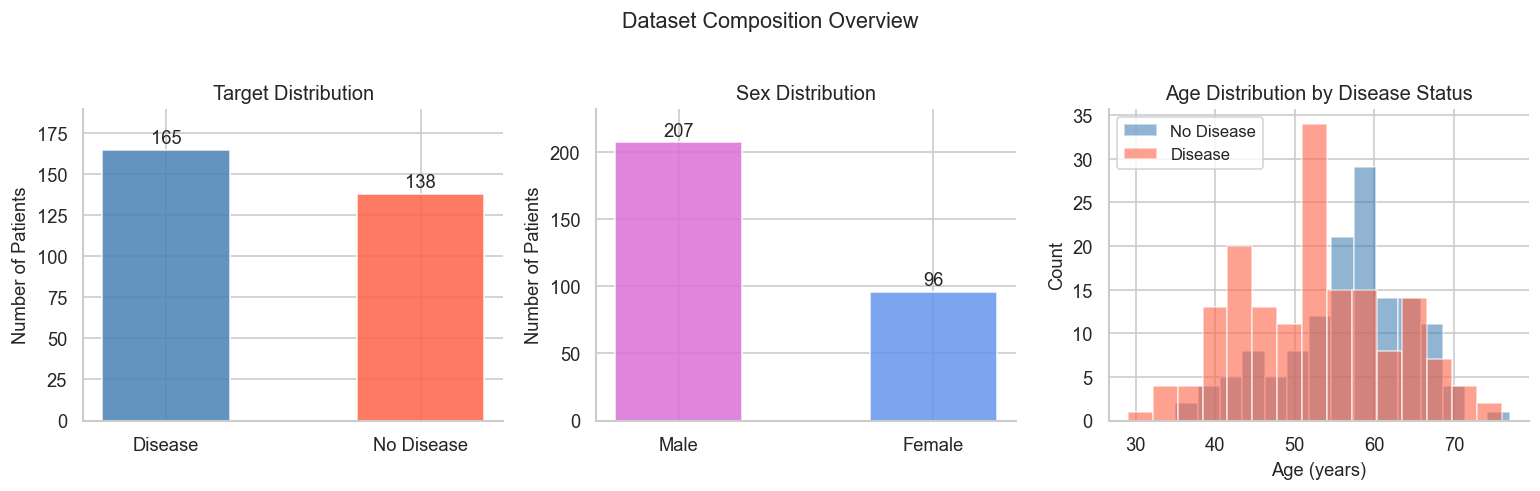

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Target distribution
target_counts = df['target'].value_counts().rename({0: 'No Disease', 1: 'Disease'})
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=11)
axes[0].set_title('Target Distribution', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_ylim(0, target_counts.max() + 25)
axes[0].spines[['top', 'right']].set_visible(False)

# Sex distribution
sex_counts = df['sex'].value_counts().rename({0: 'Female', 1: 'Male'})
bars2 = axes[1].bar(sex_counts.index, sex_counts.values,
                    color=['orchid', 'cornflowerblue'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars2, sex_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=11)
axes[1].set_title('Sex Distribution', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=11)
axes[1].set_ylim(0, sex_counts.max() + 25)
axes[1].spines[['top', 'right']].set_visible(False)

# Age distribution histogram
axes[2].hist(df[df['target'] == 0]['age'], bins=15, alpha=0.6, color='steelblue',
             label='No Disease', edgecolor='white')
axes[2].hist(df[df['target'] == 1]['age'], bins=15, alpha=0.6, color='tomato',
             label='Disease', edgecolor='white')
axes[2].set_title('Age Distribution by Disease Status', fontsize=12)
axes[2].set_xlabel('Age (years)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].legend(fontsize=10)
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Dataset Composition Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The dataset is already clean with no missing values anywhere across the 303 records, which is pretty rare for clinical data. All features come stored as numeric types, so no string parsing is needed. Categorical variables like `sex`, `cp`, and `target` are encoded as integers, which works directly with scikit-learn.

A few things worth noting from the initial look: the target variable is nearly balanced (165 disease cases, 138 no disease), so we don't have to worry about class imbalance throwing off our classifier. The dataset does lean heavily male though, 207 males versus 96 females, which is a demographic gap we'll look at in Section 3.3. For the EDA plots, we'll add readable labels for categorical columns without changing the underlying data. Before model training, we'll scale continuous features using `StandardScaler`. For more on the pandas workflow used here, check out the [pandas user guide](https://pandas.pydata.org/docs/user_guide/index.html).

---
## 3. Exploratory Data Analysis

Before fitting any models, we take a good look at the data through summary statistics, a correlation heatmap, and three statistical tests. Each test is set up to answer a specific question using the right method for that kind of data, and each one is followed by an interpretation of what the result actually means, not just whether the p-value crossed a threshold.

Here are the three questions we're tackling:
1. Do patients with heart disease show significantly different maximum heart rates? (**two-sample t-test**)
2. Is there an association between sex and heart disease prevalence? (**chi-square test**)
3. Is there a linear relationship between age and cholesterol? (**Pearson correlation**)

### 3.1 Summary Statistics and Feature Overview

In [5]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


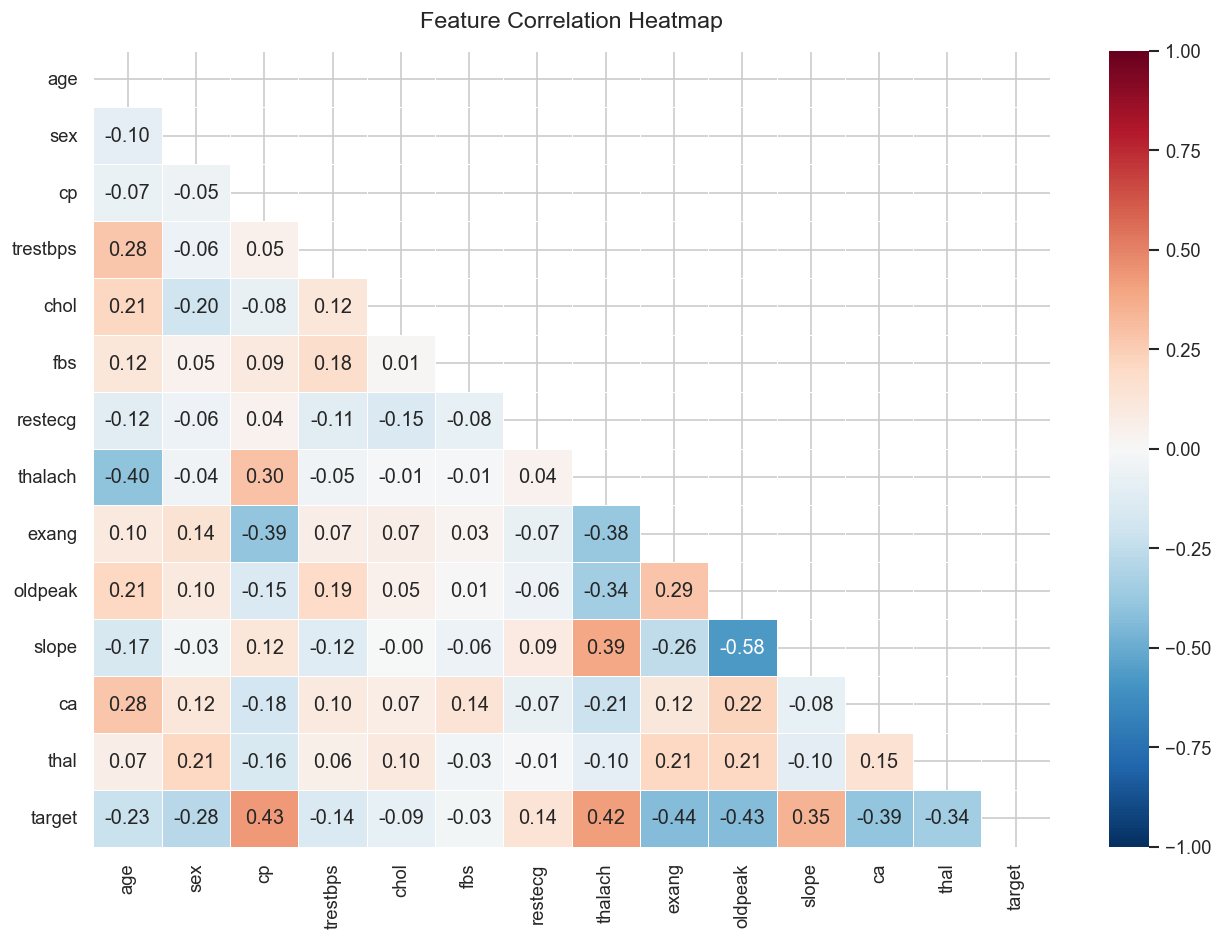

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

A few things jump out right away. The average patient is **54 years old** with a resting blood pressure of around 132 mm Hg and cholesterol around 246 mg/dL, both at the higher end of normal ranges for cardiovascular risk.

The correlation heatmap gives the best single overview of how features relate to each other. Looking at the `target` column, the strongest correlations show up with `cp` (chest pain type), `thalach` (max heart rate), `ca` (fluoroscopy vessel count), `oldpeak` (ST depression), and `exang` (exercise-induced angina). These are exactly the features we'd expect to drive our machine learning model, and as we'll see in Section 5.3, that's what ends up happening.

One interesting thing: `age` has a surprisingly weak direct correlation with `target`. It's a well-known cardiovascular risk factor in large population studies, but in this particular cohort where all patients were already referred for diagnostic workup, age by itself isn't a strong way to tell sick from healthy patients. The tests below take a closer look at some of these patterns.

### 3.1b Feature Distributions by Disease Status

The violin plots below show how the four most correlated features are distributed across disease and non-disease groups. The width of each violin at any value shows how many patients had that value, and the inner line marks the median.

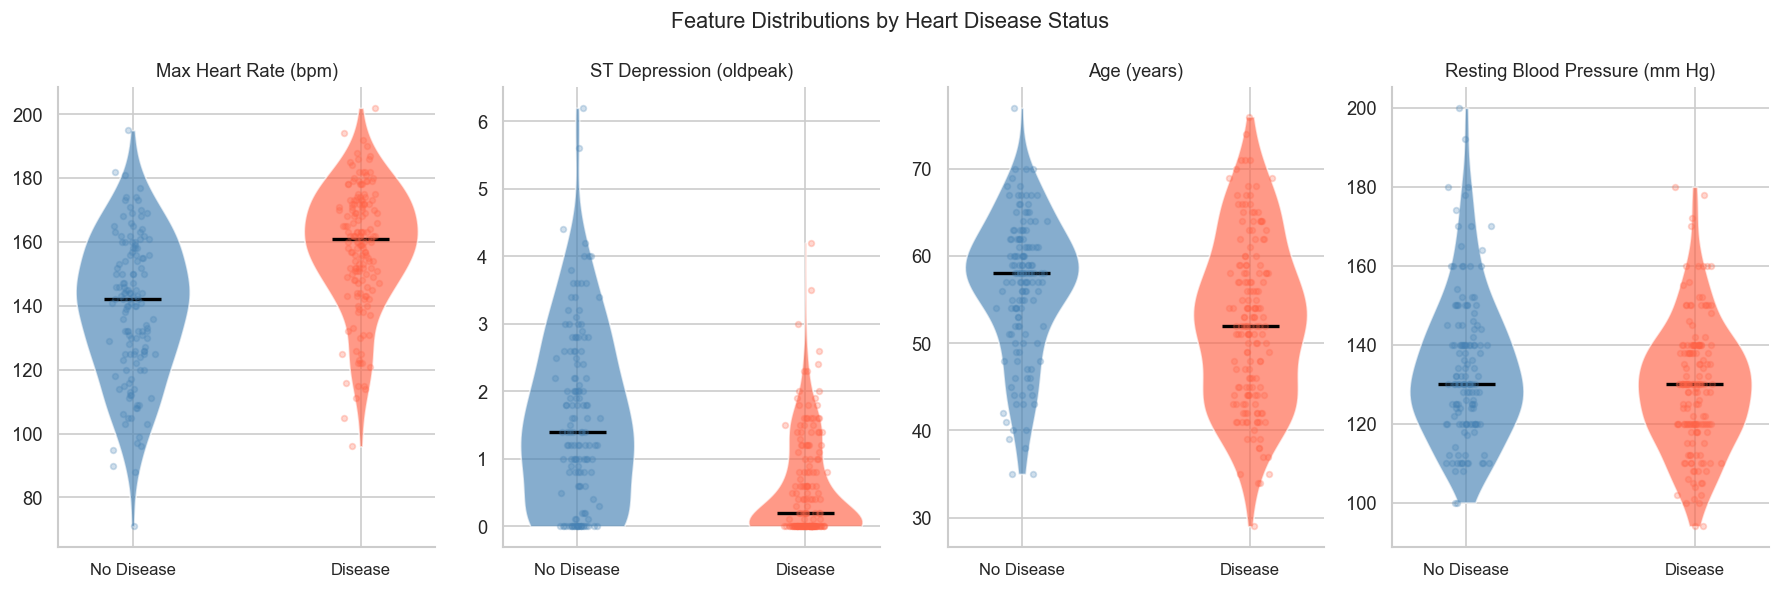

In [7]:
features_to_plot = [
    ('thalach',  'Max Heart Rate (bpm)'),
    ('oldpeak',  'ST Depression (oldpeak)'),
    ('age',      'Age (years)'),
    ('trestbps', 'Resting Blood Pressure (mm Hg)'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
palette = ['steelblue', 'tomato']
labels  = ['No Disease', 'Disease']

for ax, (feat, ylabel) in zip(axes, features_to_plot):
    groups = [df[df['target'] == 0][feat].values,
              df[df['target'] == 1][feat].values]

    parts = ax.violinplot(groups, positions=[0, 1], showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], palette):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    # overlay strip
    for i, (grp, color) in enumerate(zip(groups, palette)):
        jitter = np.random.normal(i, 0.04, size=len(grp))
        ax.scatter(jitter, grp, alpha=0.25, color=color, s=12, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(ylabel, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=13)
plt.tight_layout()
plt.show()

### 3.1c Chest Pain Type vs. Heart Disease

`cp` (chest pain type) ends up as the single most important feature in our Random Forest. It's worth looking at it directly: how are patients distributed across the four pain types, and does the disease rate differ meaningfully across them?

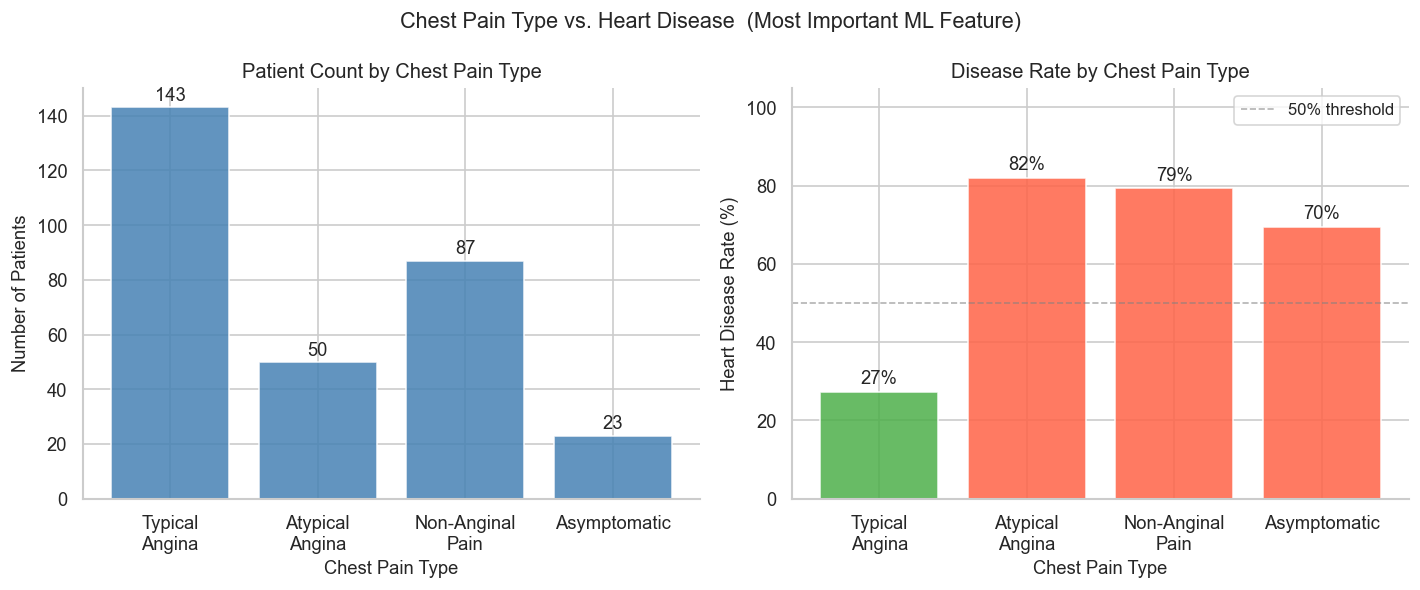

In [8]:
cp_labels  = {0: 'Typical\nAngina', 1: 'Atypical\nAngina', 2: 'Non-Anginal\nPain', 3: 'Asymptomatic'}
cp_counts  = df['cp'].value_counts().sort_index()
cp_disease = df.groupby('cp')['target'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: patient count per chest pain type
bars = axes[0].bar(
    [cp_labels[i] for i in cp_counts.index],
    cp_counts.values,
    color='steelblue', alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, cp_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=11)
axes[0].set_xlabel('Chest Pain Type', fontsize=11)
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_title('Patient Count by Chest Pain Type', fontsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: disease rate per chest pain type
bar_colors = ['#4daf4a' if v < 50 else 'tomato' for v in cp_disease.values]
bars2 = axes[1].bar(
    [cp_labels[i] for i in cp_disease.index],
    cp_disease.values,
    color=bar_colors, alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars2, cp_disease.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_xlabel('Chest Pain Type', fontsize=11)
axes[1].set_ylabel('Heart Disease Rate (%)', fontsize=11)
axes[1].set_title('Disease Rate by Chest Pain Type', fontsize=12)
axes[1].set_ylim(0, 105)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50% threshold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Chest Pain Type vs. Heart Disease  (Most Important ML Feature)', fontsize=13)
plt.tight_layout()
plt.show()

The disease rate jumps dramatically across pain types. Patients classified as asymptomatic (cp = 3) have by far the highest disease rate despite reporting no chest pain, which is a well-known clinical phenomenon called "silent ischemia." Patients with typical angina (cp = 0) actually have a lower disease rate in this sample, which might seem odd but reflects the complex relationship between symptom presentation and underlying pathology in a referred clinical population. This dramatic variation across `cp` categories explains exactly why it ranks as the most important feature in our model.

### 3.2 Test 1: Two-Sample t-test (Max Heart Rate vs. Heart Disease)

**Question:** Do patients with heart disease achieve a significantly different maximum heart rate (`thalach`) during a treadmill stress test compared to those without?

**Hypotheses:**
- **H0:** No difference in mean maximum heart rate between the two groups (μ_disease = μ_no_disease)
- **H1:** A significant difference exists (μ_disease != μ_no_disease)

We use a **two-sample independent t-test** here because `thalach` is a continuous variable and `target` splits patients into two independent groups. It's the standard approach for comparing means across two groups when the outcome is continuous. For a quick explainer on how the t-test works, check out [StatQuest: t-tests](https://www.youtube.com/watch?v=0Pd3dc1GcHc).

Mean thalach (No Disease): 139.1 bpm
Mean thalach (Disease):    158.5 bpm

t-statistic: -8.0697
p-value:     0.000000


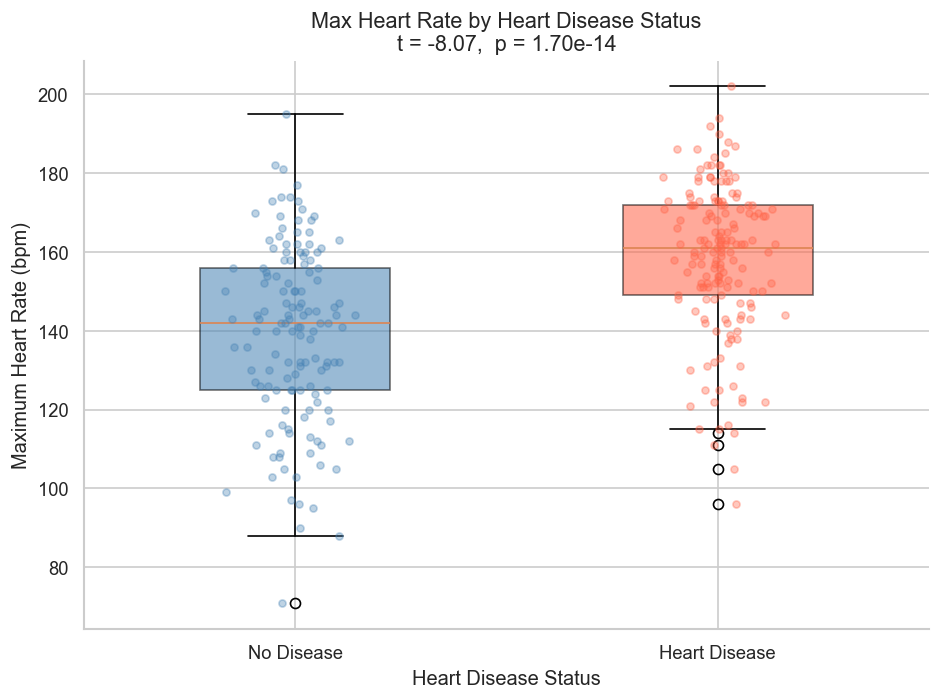

In [9]:
no_disease = df[df['target'] == 0]['thalach']
disease    = df[df['target'] == 1]['thalach']

t_stat, p_value = ttest_ind(no_disease, disease)

print(f'Mean thalach (No Disease): {no_disease.mean():.1f} bpm')
print(f'Mean thalach (Disease):    {disease.mean():.1f} bpm')
print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.6f}')

fig, ax = plt.subplots(figsize=(8, 6))

data   = [no_disease, disease]
labels = ['No Disease', 'Heart Disease']
colors = ['steelblue', 'tomato']

bp = ax.boxplot(data, patch_artist=True, tick_labels=labels, widths=0.45)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for i, (d, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.normal(i, 0.055, size=len(d))
    ax.scatter(jitter, d, alpha=0.35, color=color, s=18, zorder=3)

ax.set_ylabel('Maximum Heart Rate (bpm)', fontsize=12)
ax.set_xlabel('Heart Disease Status', fontsize=12)
ax.set_title(
    f'Max Heart Rate by Heart Disease Status\n'
    f't = {t_stat:.2f},  p = {p_value:.2e}',
    fontsize=13
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusion:** With **t = -8.07** and **p < 0.0001**, we reject the null hypothesis. Patients with heart disease hit a mean maximum heart rate of **158.5 bpm** compared to 139.1 bpm for patients without, a gap of nearly 20 bpm.

That might seem backwards at first. You'd expect diseased hearts to perform worse during exercise. But the `target` label in this dataset comes from *angiographic* findings (how blocked the arteries actually are), not from how the patient felt during the treadmill test. Patients with structural coronary disease can still push their heart rate high during a stress test. What gives them away are things like ST-segment changes and exercise-induced chest pain, which is exactly what `oldpeak` and `exang` capture. That 20 bpm gap makes `thalach` one of the strongest individual features in the dataset, something our Random Forest confirms in Section 5.3.

### 3.3 Test 2: Chi-Square Test (Sex vs. Heart Disease)

**Question:** Is there a statistically significant association between biological sex and heart disease diagnosis in this dataset?

**Hypotheses:**
- **H0:** Sex and heart disease are independent (knowing someone's sex tells us nothing about their disease status)
- **H1:** There is a significant association between sex and heart disease

We use a **chi-square test of independence** here because both `sex` and `target` are categorical variables. The chi-square test checks whether two categorical variables are associated. Since females are underrepresented in this dataset (96 vs. 207 males), we use **proportions within each sex group** for the visualization instead of raw counts, so the comparison isn't thrown off by the sample size difference. For more on chi-square, see [Khan Academy: Chi-square tests](https://www.khanacademy.org/math/statistics-probability/inference-categorical-data-chi-square-tests).

=== Contingency Table (raw counts) ===
Diagnosis  Heart Disease  No Disease
Sex                                 
Female                72          24
Male                  93         114

Chi-square statistic: 22.7172
p-value:              0.000002
Degrees of freedom:   1


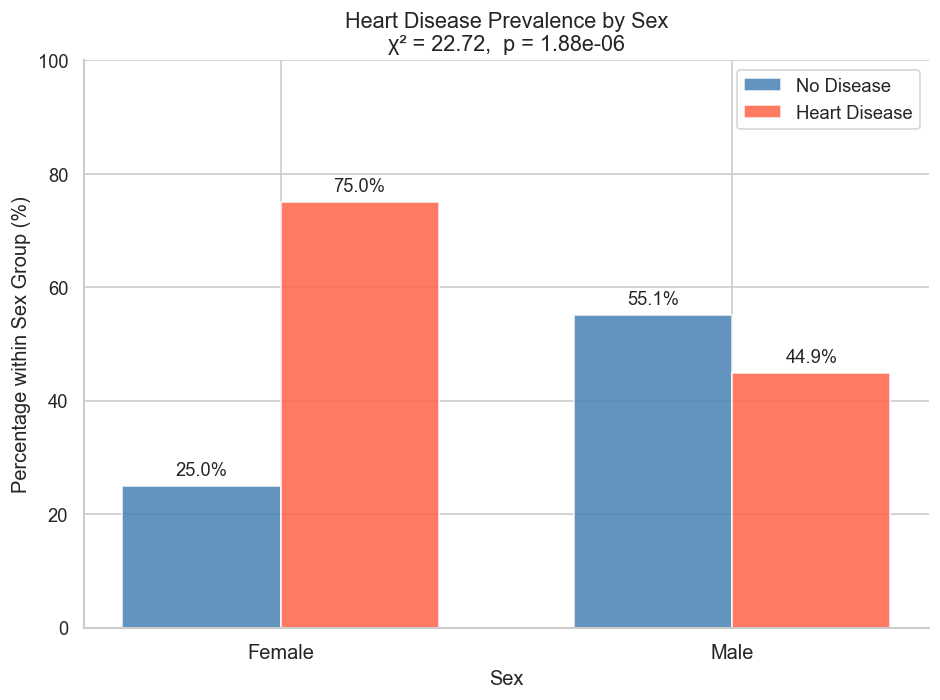

In [10]:
df_labeled = df.copy()
df_labeled['sex']    = df_labeled['sex'].map({0: 'Female', 1: 'Male'})
df_labeled['target'] = df_labeled['target'].map({0: 'No Disease', 1: 'Heart Disease'})

contingency = pd.crosstab(df_labeled['sex'], df_labeled['target'],
                           rownames=['Sex'], colnames=['Diagnosis'])
print('=== Contingency Table (raw counts) ===')
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'\nChi-square statistic: {chi2:.4f}')
print(f'p-value:              {p:.6f}')
print(f'Degrees of freedom:   {dof}')

prop_table = pd.crosstab(df_labeled['sex'], df_labeled['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 6))
x     = np.arange(len(prop_table.index))
width = 0.35

bars1 = ax.bar(x - width/2, prop_table['No Disease'],    width, label='No Disease',    color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, prop_table['Heart Disease'], width, label='Heart Disease', color='tomato',    alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Sex', fontsize=12)
ax.set_ylabel('Percentage within Sex Group (%)', fontsize=12)
ax.set_title(
    f'Heart Disease Prevalence by Sex\n'
    f'χ² = {chi2:.2f},  p = {p:.2e}',
    fontsize=13
)
ax.set_xticks(x)
ax.set_xticklabels(prop_table.index, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusion:** With **chi-squared = 22.72** and **p < 0.0001**, we reject the null hypothesis. Sex and heart disease are not independent in this dataset.

The proportional bar chart reveals something counterintuitive: **females in this dataset actually have a higher disease rate (75%) than males (44.9%)**. That seems to contradict what we know from general population studies, where males tend to face higher cardiovascular risk at younger ages. The key is that this is a *clinical referral sample*, not a random population sample. Female patients who were sent for coronary angiography were likely more severely symptomatic before being referred, since women often present with atypical symptoms and tend to be referred later in disease progression. So the 75% rate for females reflects a selection bias in who ended up in this dataset, not a population-level finding.

Even so, the association is statistically real and strong enough to justify keeping `sex` as a feature in our ML model.

### 3.4 Test 3: Pearson Correlation (Age vs. Cholesterol)

**Question:** Is there a significant linear relationship between a patient's age and their cholesterol level?

**Hypotheses:**
- **H0:** No linear correlation between age and cholesterol (rho = 0)
- **H1:** A significant linear correlation exists (rho != 0)

We use **Pearson correlation** here because both `age` and `chol` are continuous variables, and Pearson is the standard way to measure the strength and direction of a linear relationship between two continuous quantities. Cholesterol tends to build up with age, so we expect a positive correlation, but how strong that relationship actually is in this particular cohort is what we want to find out. The scatter plot below also colors points by disease status so we can see whether cholesterol separates the two groups at all. For more on Pearson correlation, see [StatQuest: Pearson correlation](https://www.youtube.com/watch?v=11c9cs6WpJU).

Pearson r:  0.2137
p-value:    0.0002
Regression: cholesterol = 1.22 × age + 180.0


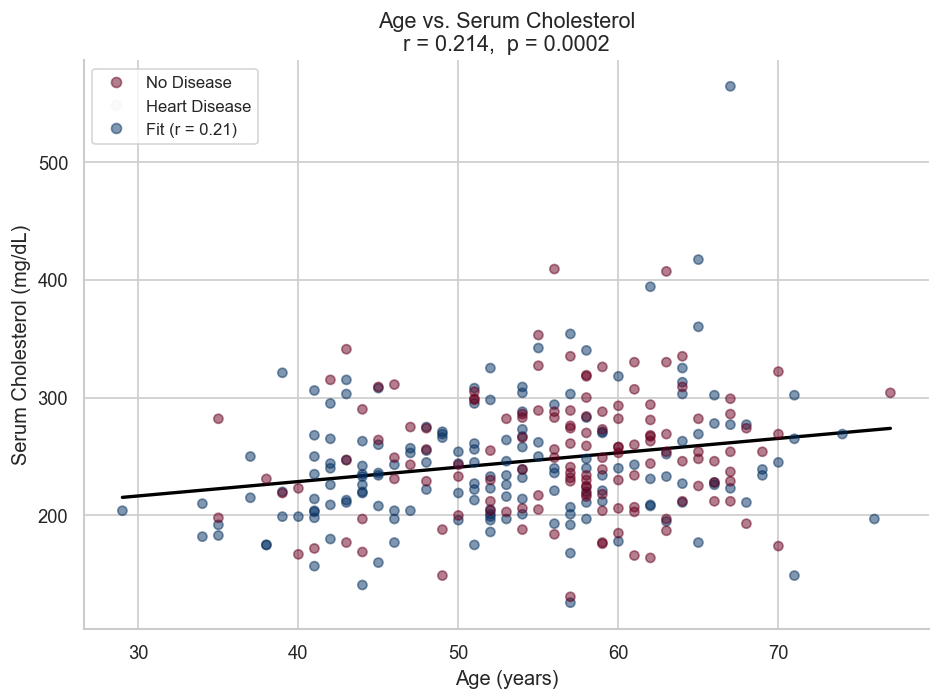

In [11]:
x = df['age']
y = df['chol']

corr, p_value = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)

print(f'Pearson r:  {corr:.4f}')
print(f'p-value:    {p_value:.4f}')
print(f'Regression: cholesterol = {m:.2f} × age + {b:.1f}')

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(x, y, alpha=0.5, c=df['target'], cmap='RdBu',
                     s=30, zorder=3, label='_nolegend_')

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2,
        label=f'y = {m:.2f}x + {b:.1f}')

handles, _ = scatter.legend_elements(prop='colors', num=2)
ax.legend(
    handles + [plt.Line2D([0], [0], color='black', linewidth=2)],
    ['No Disease', 'Heart Disease', f'Fit (r = {corr:.2f})'],
    fontsize=10, loc='upper left'
)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Serum Cholesterol (mg/dL)', fontsize=12)
ax.set_title(
    f'Age vs. Serum Cholesterol\n'
    f'r = {corr:.3f},  p = {p_value:.4f}',
    fontsize=13
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusion:** We get **r = 0.214** with **p = 0.0002**, so we reject the null hypothesis. There is a statistically significant positive relationship between age and cholesterol in this dataset.

But r = 0.214 is a pretty weak correlation. Age only explains about **4.6% of the variance** in cholesterol levels (r^2 = 0.046). So while the relationship is real and detectable with enough data, it's not particularly meaningful on its own. Cholesterol is shaped by a lot of things besides age, like diet, genetics, exercise, and medications, none of which show up in this dataset. The scatter plot makes this clear: cholesterol values are spread all over the place at any given age, and disease-positive and disease-negative patients are mixed together throughout. Cholesterol alone is not a useful way to tell whether someone has heart disease.

---
## 4. Primary Analysis: Machine Learning

### 4.1 Why Random Forest?

The EDA made it clear that heart disease prediction here isn't a simple linear problem. Multiple features interact with each other, and the correlation heatmap showed no single feature that cleanly separates the two groups on its own. That points us toward an ensemble method.

We went with **Random Forest** as our main classifier for three reasons:
1. It handles the mix of continuous and categorical features in this dataset without needing extra encoding steps
2. It is not thrown off by the outliers we saw in `chol` and `trestbps`
3. It gives us **feature importance scores**, which directly answers Research Question 2

We also train a **Logistic Regression** model as a baseline. It's the simplest binary classifier out there, so it gives us a good performance floor to compare against. If Random Forest can't clearly beat logistic regression on this dataset, the added complexity isn't worth it.

For a deeper look at how Random Forests work, see [Breiman (2001)](https://link.springer.com/article/10.1023/A:1010933404324) or [this intuitive guide](https://towardsdatascience.com/understanding-random-forest-58381e0602d2).

### 4.2 Train/Test Split and Feature Scaling

In [12]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f'Training set:  {X_train_sc.shape[0]} samples')
print(f'Test set:      {X_test_sc.shape[0]} samples')
print(f'\nClass balance in training set:')
print(y_train.value_counts().rename(index={0: 'No Disease', 1: 'Disease'}))
print(f'\nClass balance in test set:')
print(y_test.value_counts().rename(index={0: 'No Disease', 1: 'Disease'}))

Training set:  242 samples
Test set:      61 samples

Class balance in training set:
target
Disease       132
No Disease    110
Name: count, dtype: int64

Class balance in test set:
target
Disease       33
No Disease    28
Name: count, dtype: int64


We hold out 20% of the data (61 patients) as a test set and use the remaining 80% (242 patients) for training. The `stratify=y` argument makes sure both splits keep the same 55/45 class ratio, which matters when the dataset is small.

We apply `StandardScaler` to put all features on the same scale (zero mean, unit variance). Random Forest doesn't technically need this since it makes splits based on feature values rather than magnitudes, but Logistic Regression does. Scaling both models ensures a fair comparison. One important detail: we fit the scaler on training data only, then apply that same transformation to the test set. Fitting on the full dataset before splitting would let test-set information leak into the training process and inflate our performance estimates.

### 4.3 Model Training

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

rf_cv = cross_val_score(rf, X_train_sc, y_train, cv=5, scoring='accuracy')
lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='accuracy')

print('=== 5-Fold Cross-Validation Accuracy (training set) ===')
print(f'Random Forest:    {rf_cv.mean():.3f} ± {rf_cv.std():.3f}')
print(f'Logistic Regression: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}')

=== 5-Fold Cross-Validation Accuracy (training set) ===
Random Forest:    0.831 ± 0.047
Logistic Regression: 0.831 ± 0.041


### 4.4 Evaluation

We evaluate both models on the held-out test set using four metrics. Each one tells you something different:

- **Accuracy:** What fraction of all predictions were correct. Useful as a general summary, but it can be misleading when class sizes are unequal, so we look at the others too.
- **Precision:** Of the patients the model flagged as having heart disease, how many actually did? Higher precision means fewer false alarms.
- **Recall (Sensitivity):** Of all patients who actually had heart disease, how many did the model catch? In clinical screening, this is the number that matters most. A missed case (false negative) can be life-threatening.
- **ROC-AUC:** The model's overall ability to tell sick patients apart from healthy ones across all possible thresholds. Scores go from 0.5 (random guessing) to 1.0 (perfect).

In [14]:
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('======  Random Forest  ======')
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

print('\n======  Logistic Regression  ======')
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

======  Random Forest  ======
              precision    recall  f1-score   support

  No Disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61

ROC-AUC: 0.9091

======  Logistic Regression  ======
              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC-AUC: 0.8690


The Random Forest hits **83.6% accuracy** and an **AUC of 0.909** on the test set, beating Logistic Regression (80.3% accuracy, AUC 0.869). An AUC above 0.9 is generally considered excellent for a clinical screening tool.

The most important number here is the **97% recall** for the Disease class. The model correctly identifies 97% of true heart disease cases in the test set, missing only one patient out of 33. That's the performance that matters most in this context: a false negative means a sick patient goes home without follow-up. The trade-off is that precision for the Disease class is lower at 78%, so some healthy patients do get flagged unnecessarily. In a real-world screening context that's the right trade-off to make.

Cross-validation accuracy was consistent between training and test performance for both models, so neither one is overfitting despite the small dataset size.

---
## 5. Visualization of Results

The three plots below each answer a different question about how the model performed and what it learned. The confusion matrix shows where mistakes were made. The ROC curve shows how well it discriminates across thresholds. The feature importance chart shows which inputs the model relied on most.

### 5.1 Confusion Matrix

The confusion matrix breaks predictions into four buckets. In sklearn's layout, the rows are the true labels and the columns are the predicted labels:
- **True Negatives (top-left):** Healthy patients correctly cleared.
- **False Positives (top-right):** Healthy patients incorrectly flagged, leading to unnecessary follow-up tests.
- **False Negatives (bottom-left):** Sick patients missed entirely. This is the worst outcome in a clinical context.
- **True Positives (bottom-right):** Sick patients correctly flagged. This is the box we want to fill.

We plot both models side-by-side so the difference is easy to see at a glance.

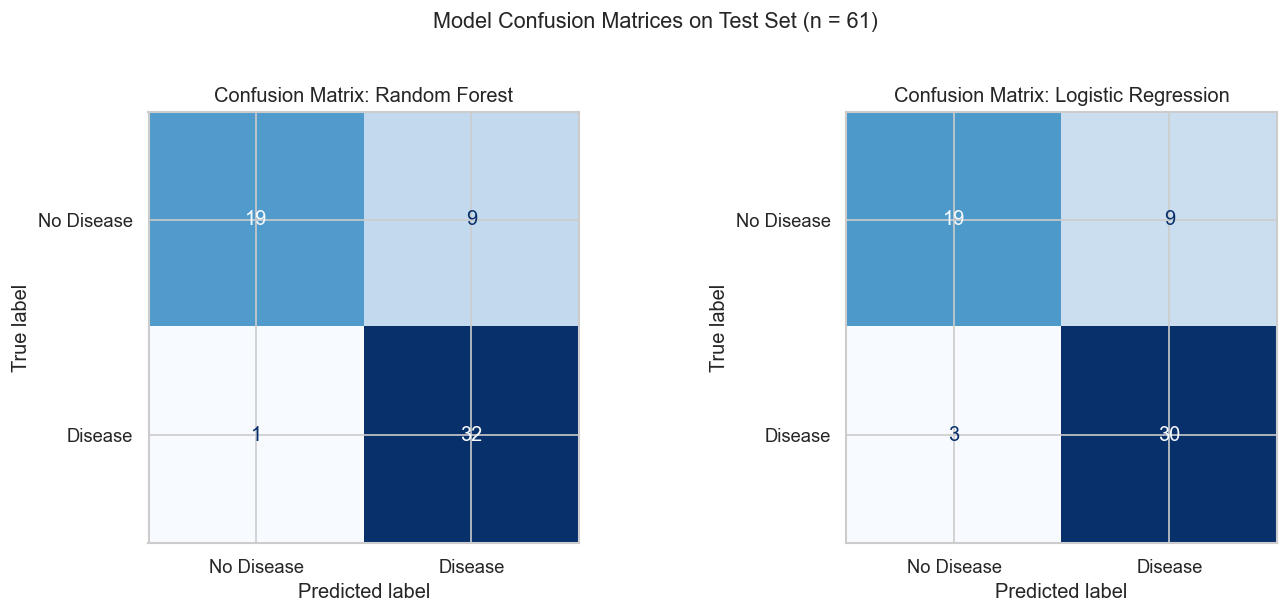

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_lr],
    ['Random Forest', 'Logistic Regression']
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Disease', 'Disease']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {title}', fontsize=12)

plt.suptitle('Model Confusion Matrices on Test Set (n = 61)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The Random Forest misses only **1 disease case** out of 33 in the test set (a 3% false negative rate), while Logistic Regression misses more. The trade-off is more false positives: some healthy patients get flagged. In a real screening setting that's an acceptable trade-off since a false positive leads to more testing, not a missed diagnosis.

### 5.2 ROC Curves

The ROC curve plots sensitivity (true positive rate) against false positive rate as the classification threshold sweeps from 0 to 1. A curve that hugs the upper-left corner means the model catches most sick patients while barely flagging any healthy ones. The **AUC** collapses that curve into a single number between 0.5 (random guessing) and 1.0 (perfect). For a clinical screening tool, you generally want to see AUC above 0.85.

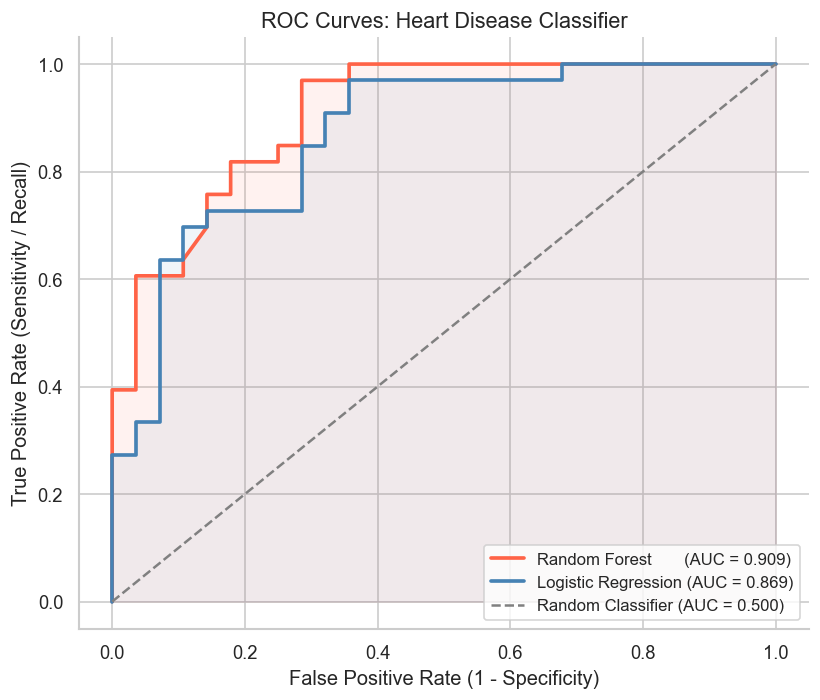

In [16]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_rf, tpr_rf, color='tomato',    lw=2.2, label=f'Random Forest       (AUC = {auc_rf:.3f})')
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2.2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier (AUC = 0.500)')

ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='tomato')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='steelblue')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves: Heart Disease Classifier', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

The Random Forest gets an **AUC of 0.909**, well above the screening threshold. Logistic Regression lands at 0.869, which is solid but noticeably weaker across the full range of thresholds. The shaded areas under each curve make the gap easy to see visually. If this were being deployed as a real clinical tool, you'd pick a threshold based on your priorities: go lower to catch more cases at the cost of more false alarms, or go higher to reduce false alarms at the cost of missing some cases.

### 5.3 Feature Importances

Random Forest computes an importance score for each feature based on how much it reduces prediction error across all trees in the ensemble. Higher score = more influence on the model's decisions. This directly answers Research Question 2.

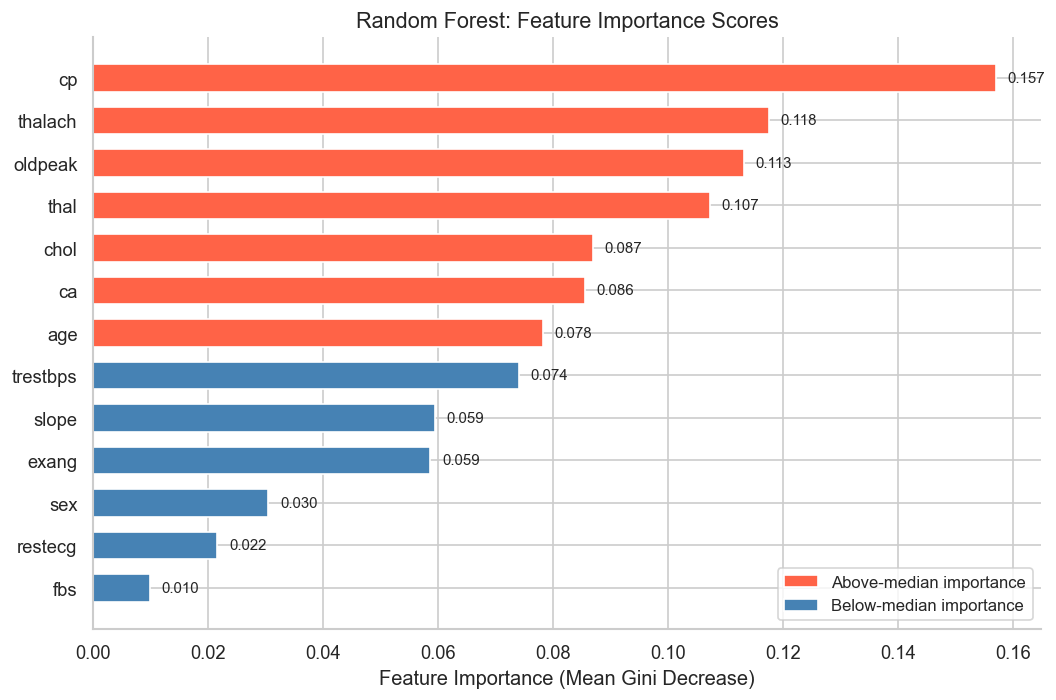

In [17]:
feature_names  = X.columns.tolist()
importances    = rf.feature_importances_
sorted_idx     = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['tomato' if importances[i] >= np.median(importances) else 'steelblue'
          for i in sorted_idx]

bars = ax.barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=colors,
    edgecolor='white',
    height=0.65
)

for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    label='Above-median importance'),
    Patch(facecolor='steelblue', label='Below-median importance')
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_xlabel('Feature Importance (Mean Gini Decrease)', fontsize=12)
ax.set_title('Random Forest: Feature Importance Scores', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Here's how the features ranked:

| Rank | Feature | Importance | Clinical Meaning |
|---|---|---|---|
| 1 | `cp` (chest pain type) | 0.157 | Type of angina is the primary symptom cardiologists look at first |
| 2 | `thalach` (max heart rate) | 0.118 | Confirmed by our t-test: nearly 20 bpm gap between groups |
| 3 | `oldpeak` (ST depression) | 0.113 | Key electrocardiographic marker from the stress test |
| 4 | `thal` (thalassemia) | 0.107 | Blood disorder directly tied to how much oxygen reaches the heart |
| 5 | `chol` (cholesterol) | 0.087 | Standard cardiovascular risk factor |
| 6 | `ca` (vessel count) | 0.086 | Number of major vessels visible via fluoroscopy |

The top features match exactly what cardiologists actually look at: chest pain type, ST changes during exercise, max heart rate, and structural cardiac findings. The fact that the ML output lines up this closely with clinical practice is a good sign the model is picking up on real patterns, not just noise in the data.

Lower-ranked features like `fbs` (fasting blood sugar, 0.010) and `restecg` (resting ECG, 0.022) add a little bit of signal but not much. Interestingly, `sex` (0.031) ends up near the bottom despite the highly significant chi-square result in Section 3.3. That's worth keeping in mind: a strong association in a single-variable test doesn't automatically translate into predictive power once all the other features are in the mix.

---
## 6. Insights and Conclusions

### What We Found

We started with three research questions. Here's where we landed on each one:

**1. Can a machine learning classifier accurately predict heart disease from non-invasive clinical measurements?**

Yes, and the numbers are pretty good. The Random Forest achieves **83.6% accuracy** and an **AUC of 0.909** on the held-out test set, with **97% recall** for the disease class (only 1 miss out of 33 true cases). The 13 non-invasive clinical features in this dataset contain enough signal to build a classifier that could realistically serve as a cheap, scalable screening tool, flagging patients who need further evaluation without requiring expensive imaging upfront.

**2. Which clinical and demographic features are the strongest predictors?**

The four most important features were **chest pain type (`cp`, 0.157)**, **maximum heart rate (`thalach`, 0.118)**, **ST depression (`oldpeak`, 0.113)**, and **thalassemia status (`thal`, 0.107)**, with a combined importance above 0.49. These are the exact same variables a cardiologist would look at first. The fact that the model's priorities match clinical practice is a good sign that it's learning something real, not just fitting noise. Standard risk factors like cholesterol and blood pressure do contribute, but they're clearly secondary to the exercise-response and structural features.

**3. Are there statistically significant associations between demographic factors and heart disease?**

Yes, with some nuance:
- **Max heart rate (t-test):** The nearly 20 bpm gap (disease group: 158.5 bpm vs. no-disease group: 139.1 bpm, p < 0.0001) is strong and directly lines up with `thalach` being the second-ranked feature.
- **Sex (chi-square):** There is a highly significant association (chi-squared = 22.72, p < 0.0001), but the direction is surprising: **females in this dataset have a 75% disease rate compared to 44.9% for males**. This is a selection bias artifact since all patients were clinical referrals, not a population-level finding.
- **Age vs. cholesterol (Pearson):** The correlation is real (r = 0.214, p = 0.0002) but weak. Age only explains about 4.6% of the variance in cholesterol. A good reminder that statistical significance and practical importance are two different things.

### Limitations

A few things to keep in mind before taking these results too far:

1. **Small dataset.** 303 samples is not enough for any kind of real-world clinical deployment. You'd want multi-center validation with thousands of patients.
2. **Old and narrow data.** Everything was collected at one clinic in the 1980s. Patient demographics and clinical practices have changed a lot since then.
3. **Selection bias.** All patients were already referred for diagnostic workup, which is why the disease rate for females (75%) looks higher than expected from population studies.
4. **Missing risk factors.** BMI, smoking history, family history, and inflammatory markers are all major cardiovascular risk factors that aren't in this dataset.
5. **Binary outcome.** The original UCI data has five severity levels (0 to 4). Collapsing that to a binary label loses information about how severe the disease actually is.

### Future Work

A few directions that would make this analysis stronger:
- Hyperparameter tuning with cross-validation to squeeze more performance out of the Random Forest
- SHAP values for patient-level explainability, which is important if you want clinicians to actually trust the model
- External validation on the Hungarian, Swiss, and VA Long Beach subsets of the UCI dataset
- Expanding the feature set with additional risk factors if a richer dataset is available

### Closing Thoughts

The biggest takeaway from this project isn't the accuracy number. It's that the model and the clinician agree on what matters. When machine learning points to the same features that doctors already use, it's a sign the analysis is on solid ground. Data science is most useful not when it replaces expert judgment, but when it puts numbers behind it.

---
## References

1. **Dataset:** Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). *Heart Disease Dataset*. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/heart+disease

2. **Heart disease statistics:** World Health Organization. (2021). *Cardiovascular diseases (CVDs) fact sheet*. https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)

3. **Random Forest:** Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32. https://link.springer.com/article/10.1023/A:1010933404324

4. **scikit-learn:** Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://scikit-learn.org

5. **Pearson correlation explained:** StatQuest with Josh Starmer. *Pearson's Correlation, Clearly Explained*. https://www.youtube.com/watch?v=11c9cs6WpJU

6. **Chi-square test explained:** Khan Academy. *Chi-square tests*. https://www.khanacademy.org/math/statistics-probability/inference-categorical-data-chi-square-tests

7. **Cleveland Clinic heart disease overview:** https://my.clevelandclinic.org/health/diseases/16898-heart-disease-an-overview